EXPLARATORY DATA ANALYSIS

In [ ]:
##IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

print("Libraries imported successfully!")

In [ ]:
##LOAD DATASET
df_clean = pd.read_csv("../data/raw/superstore.csv", encoding="cp1252")

print("Data loaded successfully!")

NOW WE START ANALYZING THE DATA ASKING ALL THE QUESTIONS AND PLOTTING SYSTEMS THAT WILL HELP US DO THE MACHINE LEARNING TECHMIQUES AND ALL

In [43]:
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

Q1- HOW HAVE THE SALES CHANGED OVER TIME??

In [44]:
monthly_sales = (
    df_clean
    .set_index("Order Date")
    .resample("MS")["Sales"]
    .sum()
    .reset_index()
)

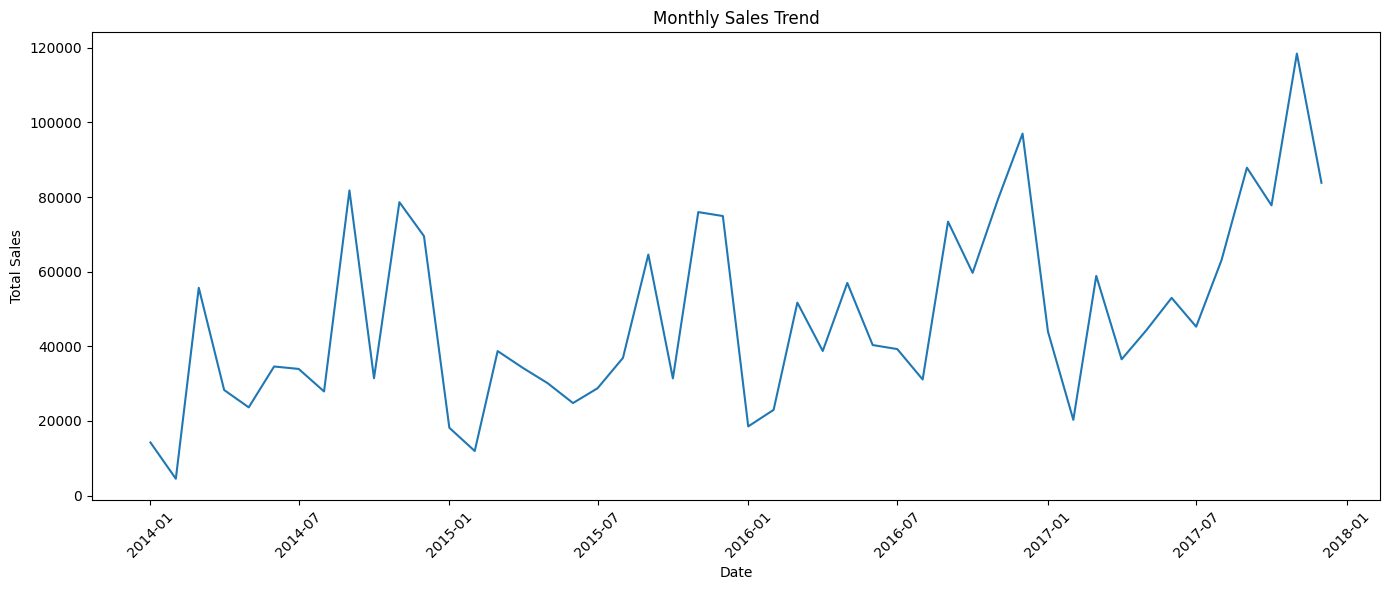

In [45]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Sales Trend

The monthly sales trend shows how total sales changed over the period from
2014 to 2017.

- Sales fluctuate considerably from month to month, indicating substantial
  short-term variation in customer demand.
- Despite these fluctuations, the overall pattern suggests an upward trend
  in sales over the four-year period.
- Sales levels toward the end of 2017 are generally higher than those
  observed during the earlier years.
- Several strong sales peaks occur toward the later months of the year.
- Noticeable declines can also be observed around the beginning of some years.
- The highest monthly sales occur near the end of 2017, reaching approximately
  $118,000.

### Business Insight

The combination of an overall upward trend and recurring peaks suggests that
the business may be experiencing both long-term growth and seasonal variation.

Understanding these patterns can help the business with demand forecasting,
inventory planning, staffing and marketing decisions.

Further time-series analysis should be performed to separate the underlying
trend from seasonal and irregular components.

Q2- WHICH CATEGORIES GENERATE THE MOST SALES

In [ ]:
category_sales = (
    df_clean
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

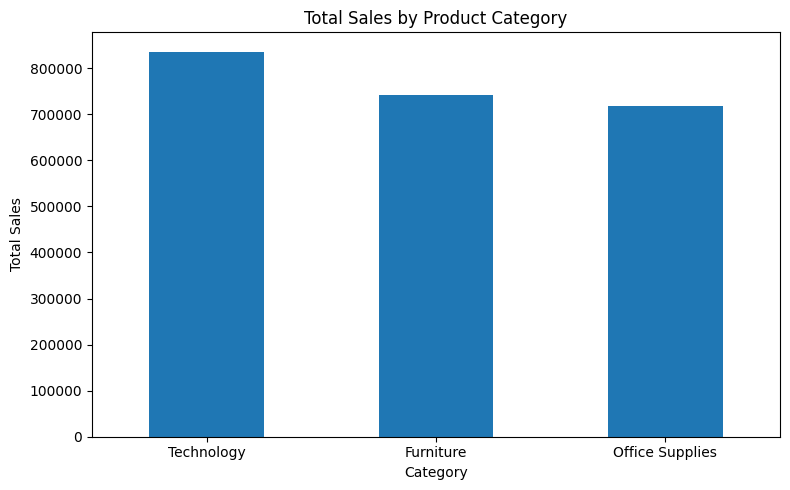

In [33]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Total Sales by Product Category

Technology generates the highest total sales, at approximately $840,000,
followed by Furniture at approximately $740,000 and Office Supplies at
approximately $720,000.

Although all three categories generate substantial sales revenue, their
profitability differs considerably.

### Business Insight

Technology is the strongest overall category because it generates both the
highest sales and the highest total profit.

Furniture presents an important business concern. Despite generating the
second-highest sales revenue, its total profit is substantially lower than
Technology and Office Supplies.

The previous sub-category analysis showed that Tables and Bookcases generate
losses, which helps explain the weak profitability of the Furniture category.

This demonstrates that high sales revenue does not necessarily imply high
profitability. Management should therefore evaluate product performance using
both sales and profit rather than sales alone.

Further investigation should examine discounts, pricing, and individual
Furniture sub-categories to determine the causes of the low profit.

Q3-WHICH SUB-CATEGORIES GENERATE THE MOST SALES

In [35]:
subcategory_sales = (
    df_clean
    .groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=True)
)

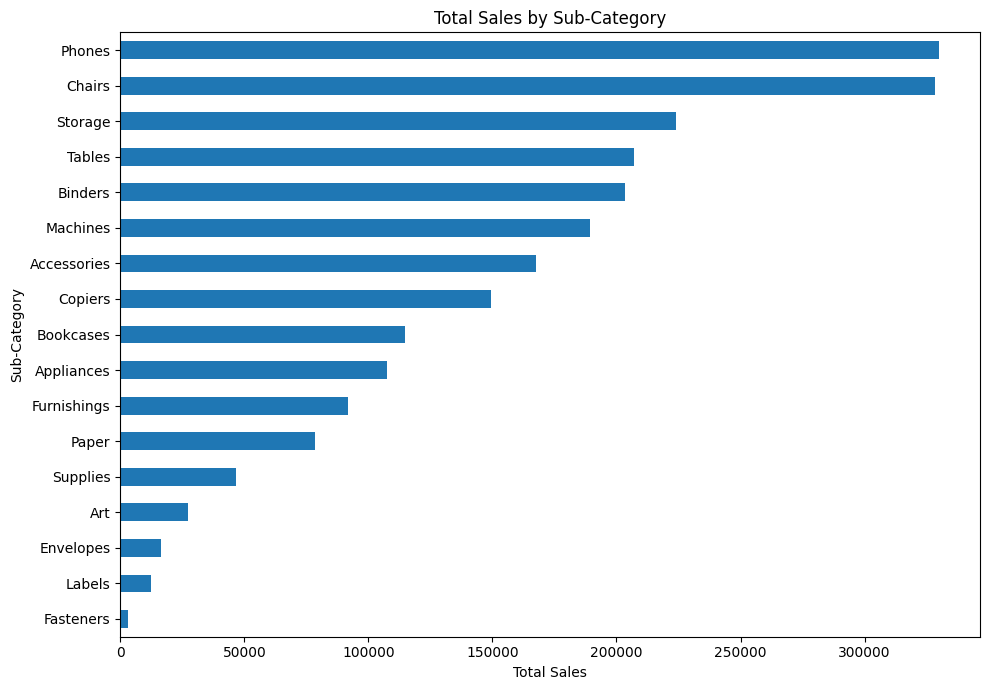

In [36]:
plt.figure(figsize=(10, 7))

subcategory_sales.plot(kind="barh")

plt.title("Total Sales by Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

### Total Sales by Product Sub-Category

The analysis shows considerable variation in sales performance across product
sub-categories.

- Phones and Chairs generate the highest total sales.
- Storage, Tables, Binders, and Machines also contribute substantial sales.
- Accessories and Copiers form another important group of revenue-generating
  products.
- Fasteners, Labels, Envelopes, Art, and Supplies generate considerably lower
  total sales.

### Business Insight

Comparing this analysis with profitability reveals an important distinction
between revenue and profit.

Tables are among the highest-selling sub-categories, but the previous profit
analysis showed that Tables generate the largest overall loss. This indicates
that strong sales revenue does not necessarily translate into profitability.

Conversely, Copiers generate less total sales than Phones and Chairs but were
identified as the most profitable sub-category.

Therefore, product performance should be evaluated using both sales and profit
rather than sales revenue alone.

The business should investigate why high-selling Tables are unprofitable,
particularly by examining discount levels, pricing, costs, and regional
performance.

Q4- WHICH CUSTOMER SEGMENT GENERATES THE MOST SALES

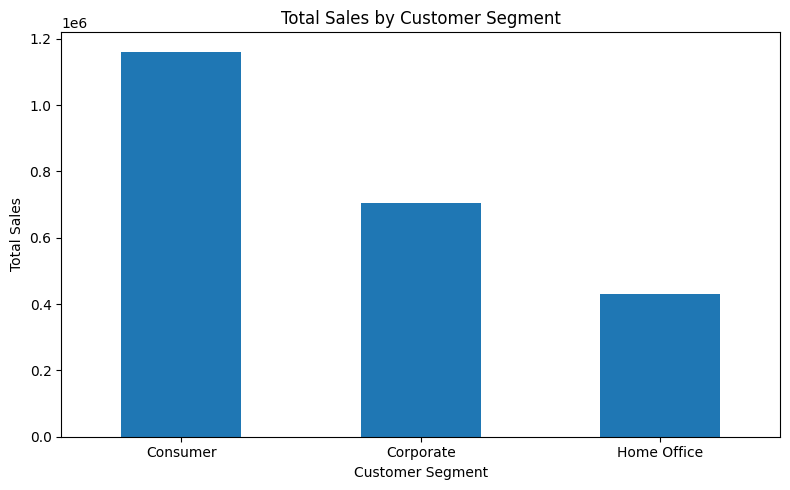

In [38]:
segment_sales = (
    df_clean
    .groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

segment_sales.plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Total Sales by Customer Segment

The analysis shows clear differences in total sales across customer segments.

- The Consumer segment generates the highest total sales, contributing
  approximately $1.16 million.
- The Corporate segment is the second-largest contributor, generating
  approximately $700,000.
- The Home Office segment generates the lowest total sales, at approximately
  $430,000.

### Business Insight

Consumers represent the largest source of sales revenue in the dataset,
making this segment particularly important to overall business performance.

However, the higher total sales from Consumers may be influenced by the
number of customers or transactions within the segment. Therefore, total
sales alone should not be interpreted as evidence that an individual
Consumer customer is more valuable than a Corporate or Home Office customer.

Further analysis could compare the number of orders, average order value,
profit, and profit margin across customer segments.

Q5- HOW DO SALES DIFFER BY SHIPPING METHOD

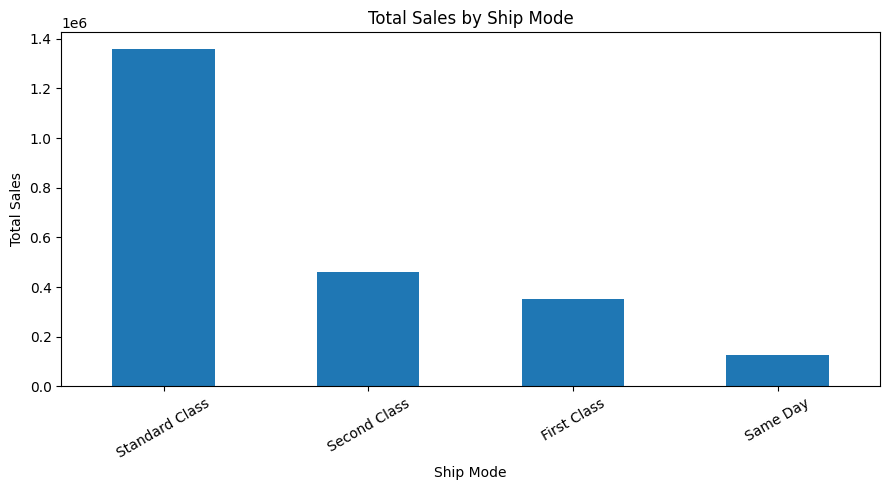

In [40]:
ship_sales = (
    df_clean
    .groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

ship_sales.plot(kind="bar")

plt.title("Total Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Total Sales by Ship Mode

The analysis shows that Standard Class generates the highest total sales by a
large margin.

- Standard Class accounts for approximately $1.35 million in sales, making it
  the dominant shipping method.
- Second Class is the second-highest contributor, generating approximately
  $460,000.
- First Class generates approximately $350,000 in sales.
- Same Day shipping contributes the lowest total sales, at approximately
  $125,000.

### Business Insight

Standard Class is clearly associated with the largest share of sales,
suggesting that it is the most commonly used or commercially significant
shipping option.

However, total sales alone do not show whether a shipping method is more
profitable or causes customers to spend more. The higher sales associated
with Standard Class may simply result from a larger number of orders using
this shipping method.

Further analysis could compare order frequency, average sales per order and
profit across shipping modes.

Q6-DOES DISCOUNT AFFECT SALES

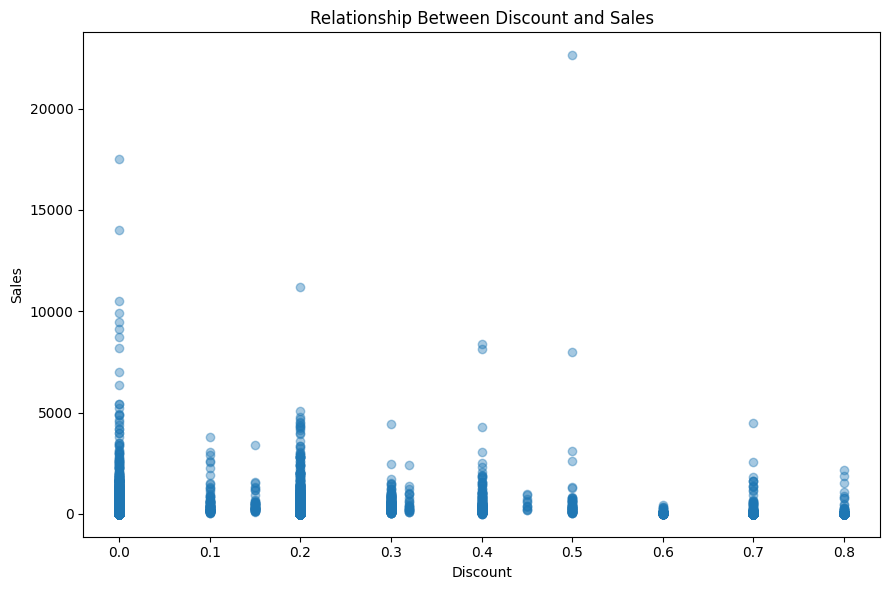

In [41]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Discount"],
    df_clean["Sales"],
    alpha=0.4
)

plt.title("Relationship Between Discount and Sales")
plt.xlabel("Discount")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

### Insight

The scatter plot shows no clear positive relationship between discount and sales.

Most transactions are concentrated at relatively low sales values across all
discount levels. Some of the highest sales transactions occur with little or
no discount, while higher discount levels do not consistently correspond to
higher sales.

This suggests that increasing discounts does not necessarily increase sales
revenue. Other factors such as product, quantity, category, customer segment,
and region may have a stronger influence on sales.

Further analysis using correlation and grouped average sales is required to
quantify the relationship between discount and sales.

Q7- DOES DISCOUNT AFFECT PROFIT

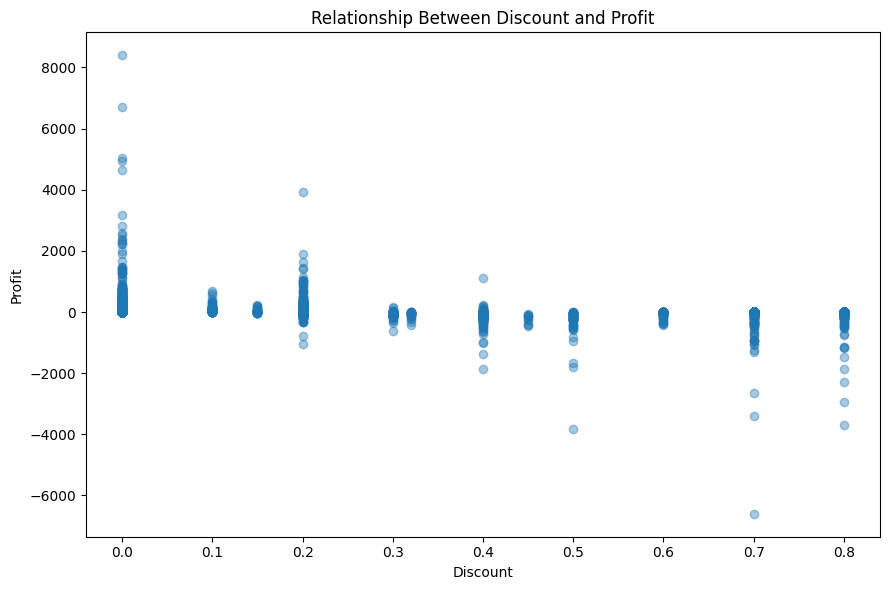

In [42]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Discount"],
    df_clean["Profit"],
    alpha=0.4
)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

### Insight

The scatter plot indicates a negative relationship between discount and profit.

Transactions with little or no discount generally produce positive profits,
including some of the highest profit values in the dataset. As the discount
rate increases, profits tend to decline and negative-profit transactions
become more common.

Higher discount levels, particularly around 50% to 80%, are associated with
substantial losses. This suggests that aggressive discounting can significantly
reduce profitability.

From a business perspective, discount strategies should therefore be carefully
managed. Higher discounts do not necessarily guarantee higher sales, while
they appear to increase the risk of financial loss.

Q8- IS SALES RELATED TO PROFIT

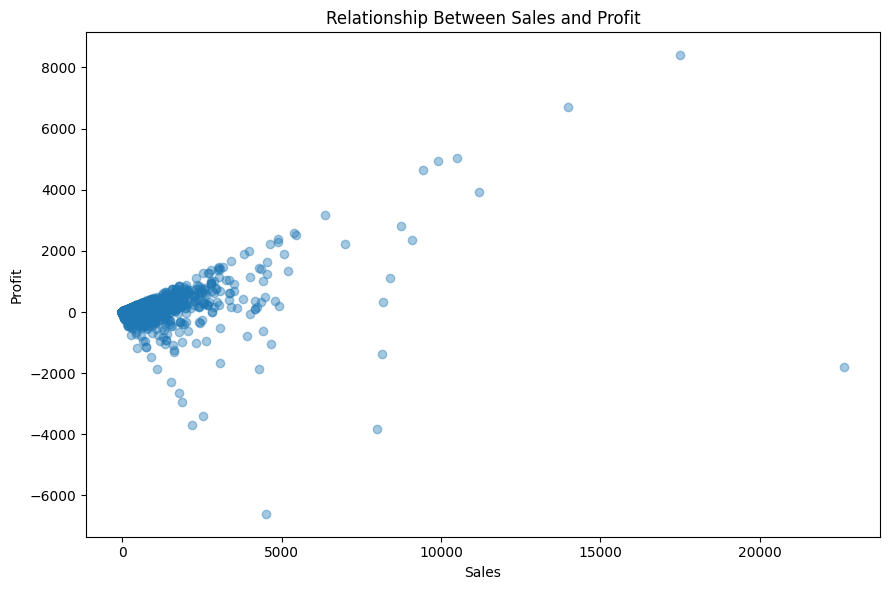

In [43]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Sales"],
    df_clean["Profit"],
    alpha=0.4
)

plt.title("Relationship Between Sales and Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

### Insight

The scatter plot shows an overall positive relationship between sales and profit.
As sales increase, profit generally tends to increase.

However, the relationship is not perfect. Several high-sales transactions
generate low or even negative profits. This demonstrates that high sales
revenue does not necessarily guarantee profitability.

The presence of large loss-making transactions suggests that other factors,
such as discount levels, product category and product margins, influence
profitability.

From a business perspective, the company should therefore evaluate both
sales revenue and profitability when assessing performance rather than
focusing on sales alone.

CALCULATING CORELATIONS

In [ ]:
correlation_matrix = df_clean[
    ["Sales", "Quantity", "Discount", "Profit"]
].corr()

correlation_matrix

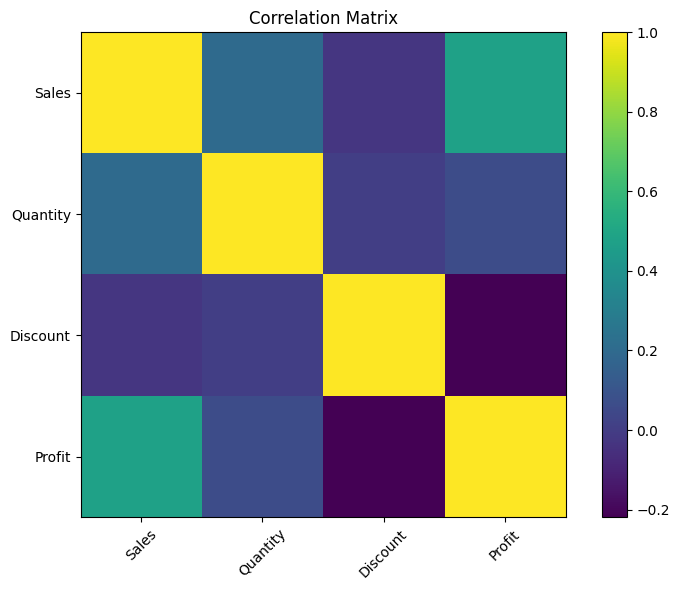

In [45]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

### Correlation Matrix Insights

The correlation matrix provides an overview of the relationships between
Sales, Quantity, Discount and Profit.

- **Sales and Profit** show the strongest positive relationship, indicating
  that higher sales are generally associated with higher profits. However,
  high sales do not always guarantee profitability.

- **Sales and Quantity** have a positive relationship, suggesting that
  transactions involving larger quantities tend to generate higher sales.

- **Discount and Profit** show a negative relationship. This indicates that
  higher discount levels tend to be associated with lower profitability.

- **Discount and Sales** have a relatively weak relationship, suggesting that
  increasing discounts does not necessarily result in substantially higher
  sales.

Overall, the analysis suggests that discounting should be managed carefully.
Higher discounts may reduce profitability without producing a corresponding
increase in sales revenue.

Q9- WHICH CATEGORIES ARE MORE PROFITABLE

In [ ]:
category_profit = (
    df_clean
    .groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

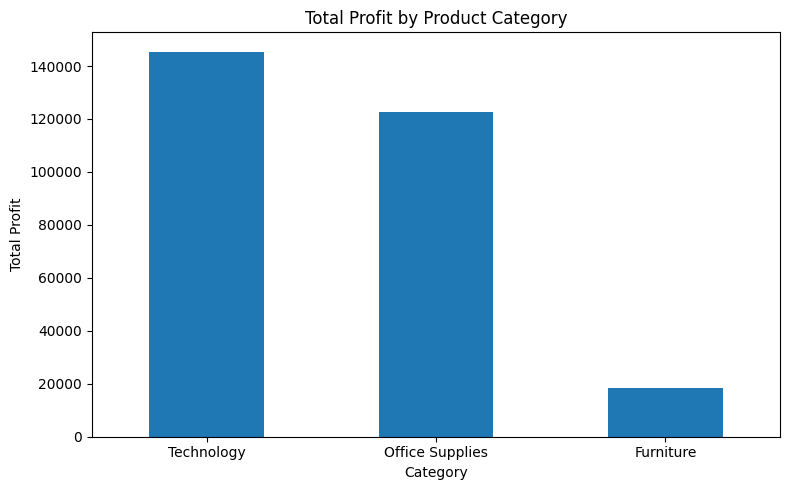

In [18]:
plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Total Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Total Profit by Product Category

The analysis shows substantial differences in profitability across the three
product categories.

- Technology is the most profitable category, generating approximately
  $145,000 in total profit.
- Office Supplies is the second most profitable category, generating
  approximately $122,000.
- Furniture generates only approximately $18,000 in profit, significantly
  lower than the other two categories.

### Business Insight

Technology represents the strongest category in terms of overall profitability,
followed by Office Supplies.

Furniture requires particular attention because its profitability is
substantially lower than the other categories. The earlier sub-category
analysis provides additional insight into this result, showing that Tables and
Bookcases generate losses.

Management should therefore investigate the pricing, discounting and cost
structure of poorly performing Furniture sub-categories rather than evaluating
the Furniture category based only on its sales revenue.

The results also demonstrate the importance of analysing both sales and profit.
A category can generate substantial revenue without necessarily generating
equally strong profit.

Q10- WHICH SUB-CATEGORIES ARE MOST PROFITABLE

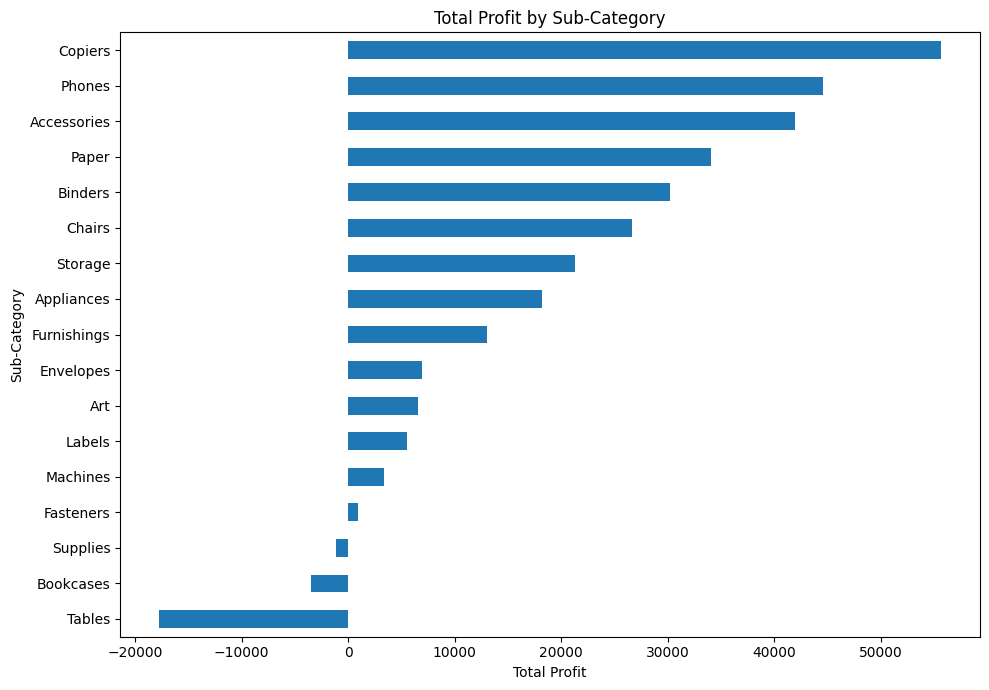

In [46]:
subcategory_profit = (
    df_clean
    .groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

subcategory_profit.plot(kind="barh")

plt.title("Total Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

### Profitability by Product Sub-Category

The analysis reveals significant differences in profitability across product
sub-categories.

- Copiers generate the highest total profit, making them the strongest
  performing sub-category.
- Phones and Accessories are the next most profitable sub-categories.
- Paper, Binders, and Chairs also make substantial positive contributions
  to overall profit.
- Most product sub-categories generate positive profit, although their
  contribution varies considerably.
- Tables are the least profitable sub-category and generate a substantial
  overall loss.
- Bookcases also generate negative profit, while Supplies show a small loss.

### Business Insight

The results demonstrate that sales performance should not be evaluated using
revenue alone. Some product groups may generate sales while contributing
little or negative profit.

The business could prioritize high-performing sub-categories such as Copiers,
Phones, and Accessories while investigating the causes of losses associated
with Tables and Bookcases. Possible factors worth investigating include
discount levels, pricing, shipping costs, and regional performance.

Q11- IS THERE MONTHLY SEASONALITY

In [47]:
df_clean["Month"] = df_clean["Order Date"].dt.month

In [49]:
monthly_seasonality = (
    df_clean
    .groupby("Month")["Sales"]
    .mean()
)

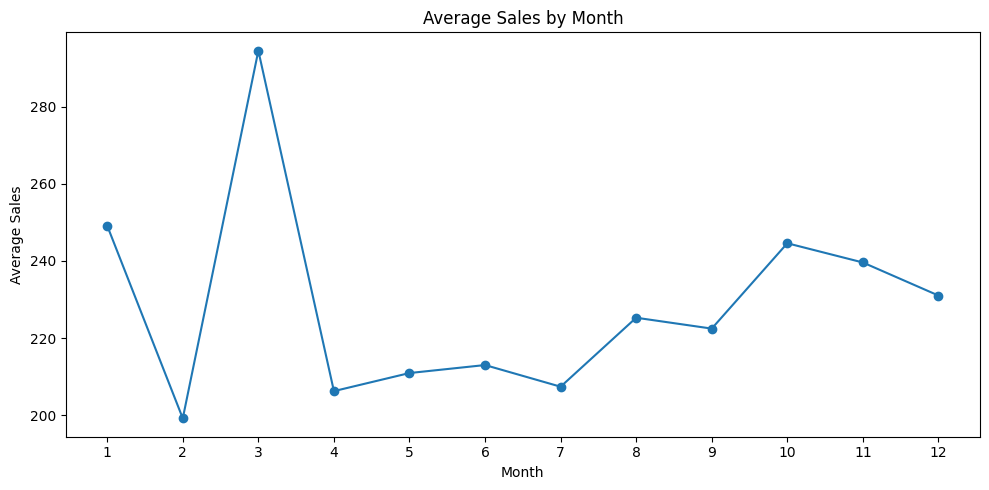

In [50]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o"
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

### Monthly Sales Seasonality Insights

The monthly sales analysis suggests that sales exhibit some seasonal variation
throughout the year.

- March records the highest average sales, indicating a strong sales period.
- February has the lowest average sales.
- Average sales decline considerably after March and remain relatively lower
  during the middle months of the year.
- Sales begin to increase again from around August, with relatively strong
  performance in October and November.
- December shows a slight decline compared with October and November.

Overall, the results suggest that customer purchasing behaviour may vary by
month, with particularly strong average sales in March and during parts of the
final quarter of the year.

However, further analysis across individual years would be required to confirm
whether these patterns consistently repeat and therefore represent true
seasonality.

Q11-HOW DOES QUANTITY RELATE TO SALES

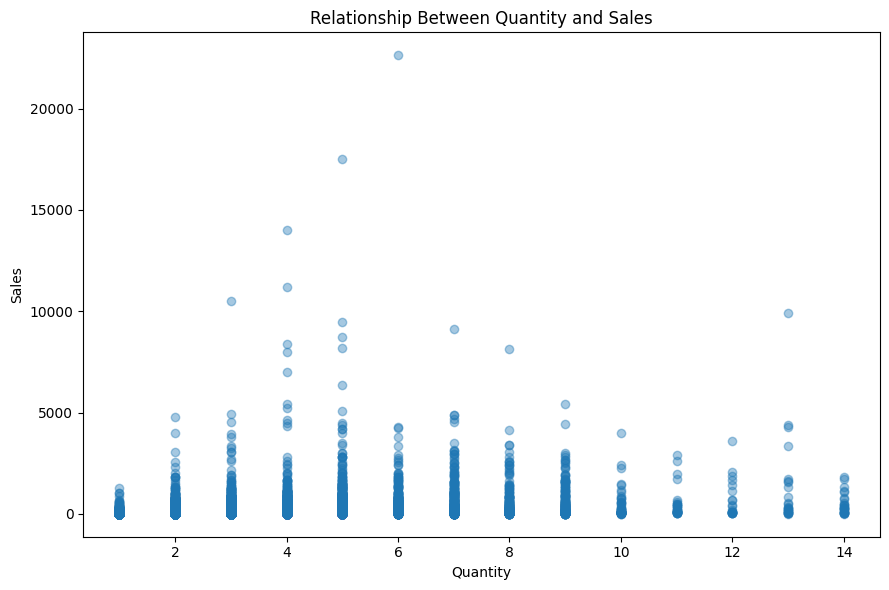

In [51]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_clean["Quantity"],
    df_clean["Sales"],
    alpha=0.4
)

plt.title("Relationship Between Quantity and Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

### Relationship Between Quantity and Sales

The scatter plot shows that quantity has some relationship with sales, but the
relationship is not strongly linear.

Most transactions are concentrated at lower and medium quantities, particularly
between approximately 2 and 9 units.

Some of the highest sales values occur at quantities between 3 and 6. However,
increasing the quantity does not consistently result in higher sales. Several
transactions with high quantities still have relatively low sales values.

This indicates that quantity alone does not determine the value of a sale.
Other factors, such as the product being purchased, product price, category,
and discount, are also likely to influence total sales.

Therefore, quantity can be considered a useful explanatory feature, but it
should be combined with other variables when predicting sales.

SALES BY CATEGORY OVER TIME

In [52]:
category_monthly = (
    df_clean
    .groupby([
        pd.Grouper(key="Order Date", freq="MS"),
        "Category"
    ])["Sales"]
    .sum()
    .reset_index()
)

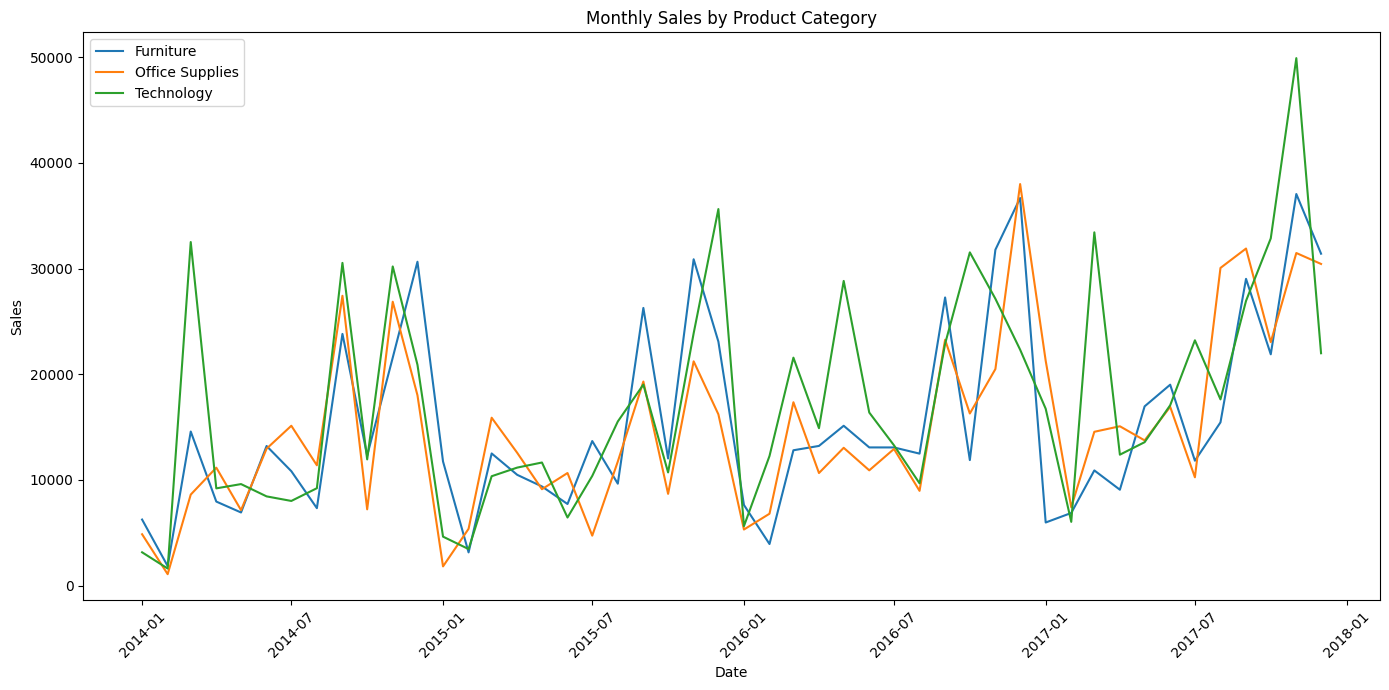

In [25]:
plt.figure(figsize=(14, 7))

for category in category_monthly["Category"].unique():

    data = category_monthly[
        category_monthly["Category"] == category
    ]

    plt.plot(
        data["Order Date"],
        data["Sales"],
        label=category
    )

plt.title("Monthly Sales by Product Category")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

Monthly sales fluctuate considerably across all three product categories, indicating that sales are not evenly distributed throughout the year.

Technology shows some of the largest sales peaks and reaches the highest monthly sales level toward the end of 2017. Furniture and Office Supplies also experience periods of strong sales, but their performance varies substantially from month to month.

Toward the later part of the dataset, particularly in 2017, all three categories generally reach higher sales levels than in the earlier years. This suggests an overall increase in sales activity over time.

However, no single category consistently leads every month. The frequent fluctuations indicate that category performance varies depending on the period.